In [1]:
# Clustering—an unsupervised machine learning approach used to group data based on similarity—is used 
#for work in network analysis, market segmentation, search results grouping, medical imaging, and 
#anomaly detection. K-means clustering is one of the most popular and easy to use clustering algorithms.

In [2]:
#Clustering is an unsupervised machine learning technique that groups similar data points together, 
#with applications spanning network analysis, market segmentation, medical imaging, and anomaly 
#detection. K-means is one of the most popular clustering algorithms.

##### 1. Collect Data

In [3]:
import pandas as pd
customers = pd.read_csv('mallcustomers.csv')
customers

,CustomerID,Gender,Age,Income,SpendingScore
0,1,Male,19,15000,39
1,2,Male,21,15000,81
2,3,Female,20,16000,6
3,4,Female,23,16000,77
4,5,Female,31,17000,40
...,...,...,...,...,...
195,196,Female,35,120000,79
196,197,Female,45,126000,28
197,198,Male,32,126000,74
198,199,Male,32,137000,18


##### 2. Explore the Data

In [4]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     200 non-null    int64 
 1   Gender         200 non-null    object
 2   Age            200 non-null    int64 
 3   Income         200 non-null    int64 
 4   SpendingScore  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
customers.describe()

,CustomerID,Age,Income,SpendingScore
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60560.000000,50.200000
std,57.879185,13.969007,26264.721165,25.823522
min,1.000000,18.000000,15000.000000,1.000000
25%,50.750000,28.750000,41500.000000,34.750000
50%,100.500000,36.000000,61500.000000,50.000000
75%,150.250000,49.000000,78000.000000,73.000000
max,200.000000,70.000000,137000.000000,99.000000


In [6]:
# Visual exploration of the data set gives some additional insight.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

C:\Users\dkhan\AppData\Local\Temp\ipykernel_21304\1015319707.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=customers,


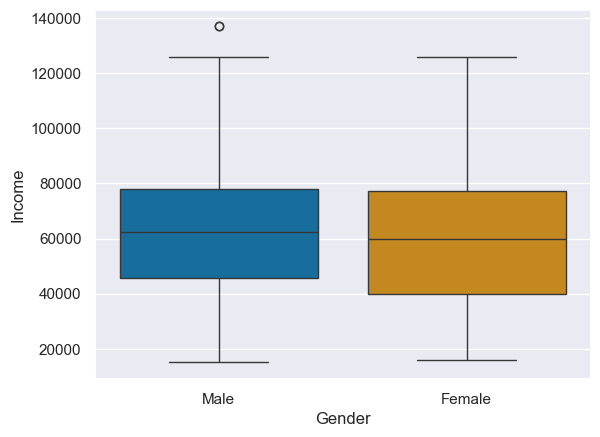

In [8]:
ax = sns.boxplot(data=customers,
                     x='Gender',
                     y='Income',
                     palette='colorblind')

C:\Users\dkhan\AppData\Local\Temp\ipykernel_21304\2345842016.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=customers,


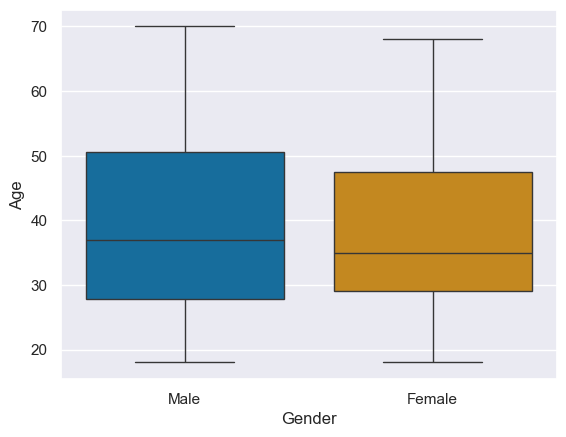

In [9]:
ax = sns.boxplot(data=customers,
                     x='Gender',
                     y='Age',
                     palette='colorblind')

C:\Users\dkhan\AppData\Local\Temp\ipykernel_21304\1987463404.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=customers,


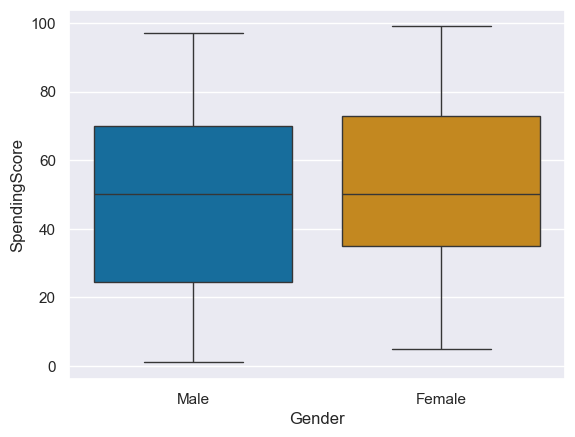

In [10]:
ax = sns.boxplot(data=customers,
                     x='Gender',
                     y='SpendingScore',
                     palette='colorblind')

In [11]:
# Above three box plots show there are no sigificant difference between the plots.

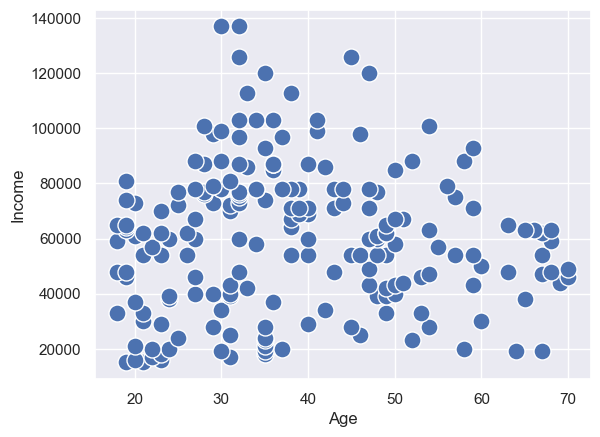

In [12]:
ax = sns.scatterplot(data=customers,
                     x='Age',
                     y='Income',
                     s=150)

In [13]:
# it shows the relationship

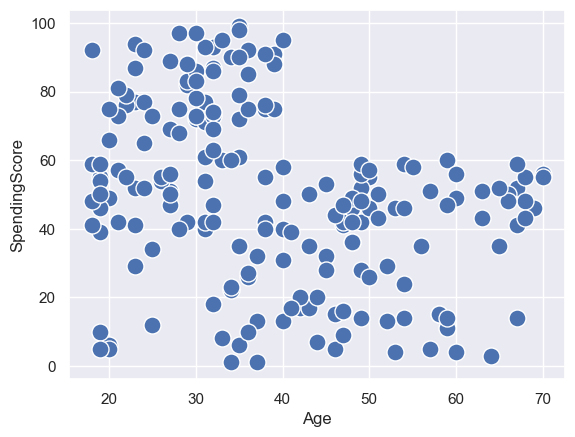

In [14]:
ax = sns.scatterplot(data=customers,
                     x='Age',
                     y='SpendingScore',
                     s=150)

In [15]:
# it shows the strong relationship

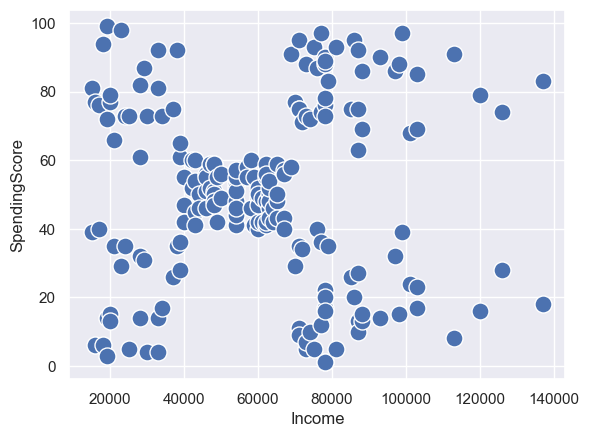

In [16]:
ax = sns.scatterplot(data=customers,
                     x='Income',
                     y='SpendingScore',
                     s=150)

In [17]:
# it shows the linear relation

###### 3. Preparation of Data

In [18]:
customers[['Income', 'SpendingScore']].describe().round(2)

,Income,SpendingScore
count,200.00,200.00
mean,60560.00,50.20
std,26264.72,25.82
min,15000.00,1.00
25%,41500.00,34.75
50%,61500.00,50.00
75%,78000.00,73.00
max,137000.00,99.00


In [19]:
# Here std deviation is significantly different. We need to normalize or standardrize these two features

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [21]:
customers_scaled = scaler.fit_transform(customers[['Income', 'SpendingScore']])

In [22]:
customers_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

In [23]:
customers_scaled = pd.DataFrame(customers_scaled, columns=['Income', 'SpendingScore'])

In [24]:
customers_scaled

,Income,SpendingScore
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980
...,...,...
195,2.268791,1.118061
196,2.497807,-0.861839
197,2.497807,0.923953
198,2.917671,-1.250054


In [25]:
customers_scaled.describe().round(2)

,Income,SpendingScore
count,200.00,200.00
mean,-0.00,-0.00
std,1.00,1.00
min,-1.74,-1.91
25%,-0.73,-0.60
50%,0.04,-0.01
75%,0.67,0.89
max,2.92,1.89


In [26]:
# As expected standard deviation 1 and mean zero, which is also called z-score normalization.

##### 3. Create the Clusture

In [27]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3, n_init=25, random_state=1234) # default is 10 for n_init)

In [28]:
km.fit(customers_scaled)

C:\Users\dkhan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",25
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",1234
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [29]:
km.labels_

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1])

In [30]:
km.inertia_

157.7040081503595

##### 4. Evaluate and Visualize the Clustures

In [31]:
pd.Series(km.labels_).value_counts().sort_index()

0     38
1     39
2    123
Name: count, dtype: int64

In [32]:
# first culusters has 38 customers, and then 39 and 123. May be first cluster is not appropriate.

In [33]:
km.cluster_centers_ 

array([[ 1.00919971, -1.22553537],
       [ 0.99158305,  1.23950275],
       [-0.62618966, -0.01439238]])

In [34]:
cluster_centers = pd.DataFrame(km.cluster_centers_, columns=['Income', 'SpendingScore'])
cluster_centers

,Income,SpendingScore
0,1.009200,-1.225535
1,0.991583,1.239503
2,-0.626190,-0.014392


In [35]:
#Set the plot

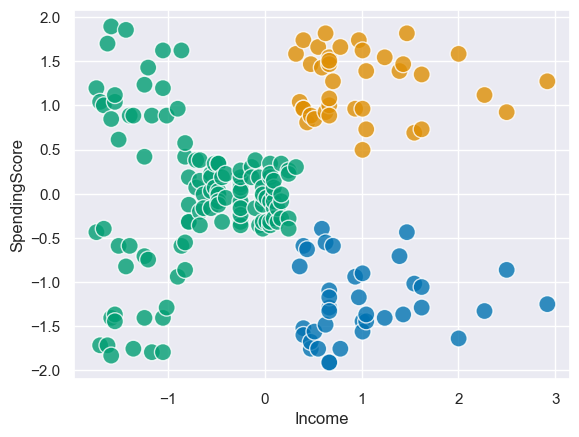

In [36]:
ax = sns.scatterplot(data=customers_scaled,
                     x='Income',
                     y='SpendingScore',
                     hue=km.labels_,
                     palette='colorblind',
                     alpha=0.8,
                     s=150,
                     legend=False)

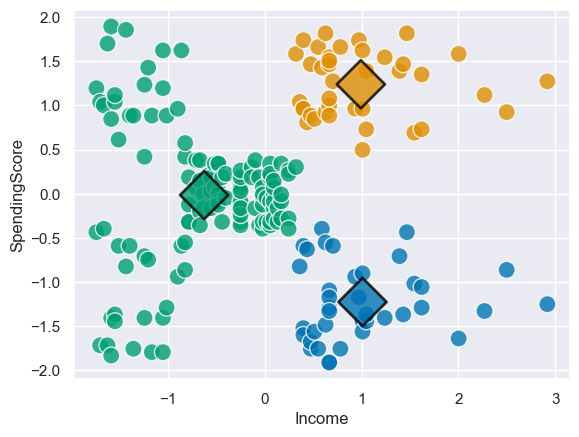

In [37]:
# First plot the data points
ax = sns.scatterplot(data=customers_scaled,
                     x='Income',
                     y='SpendingScore',
                     hue=km.labels_,
                     palette='colorblind',
                     alpha=0.8,
                     s=150,
                     legend=False)

# Then overlay the cluster centers
ax = sns.scatterplot(data=cluster_centers,
                     x='Income',
                     y='SpendingScore',
                     hue=cluster_centers.index,
                     palette='colorblind',
                     alpha=0.8,
                     s=600,
                     marker='D',
                     ec='black',
                     legend=False)

##### 5. Choose the Right Number of Cluster

In [38]:
# The within clusture sum of square (wcss)

C:\Users\dkhan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dkhan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dkhan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dkhan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

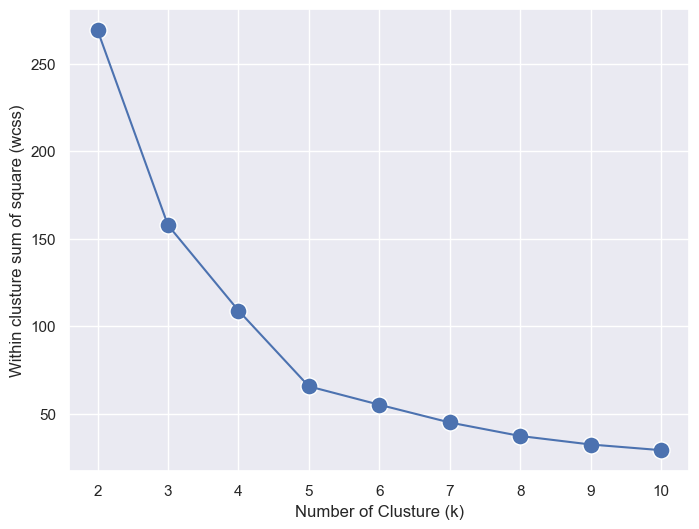

In [39]:
wcss = []
for k in range (2,11): # 11 — because we want to test K = 2 to 10 clusters (see plot below).
    km = KMeans(n_clusters=k, n_init=25, random_state=1234)
    km.fit(customers_scaled)
    wcss.append(km.inertia_)

wcss_series = pd.Series(wcss, index=range(2,11))

plt.figure(figsize=(8,6))
ax = sns.lineplot(y=wcss_series, x=wcss_series.index)
ax = sns.scatterplot(y=wcss_series, x=wcss_series.index, s=150)
ax = ax.set(xlabel='Number of Clusture (k)', ylabel='Within clusture sum of square (wcss)')

In [40]:
# Plot suggest that the appropriate value for k, the elbow, likely to 5. The elbow is a point of
# inflection, the point where increasing k, no longer reduces the wcss significantly. Here we run k 
# values from 2 to 10.
# This is first approach. The second approach is below.

##### The Average Silhouette Score

C:\Users\dkhan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dkhan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dkhan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dkhan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

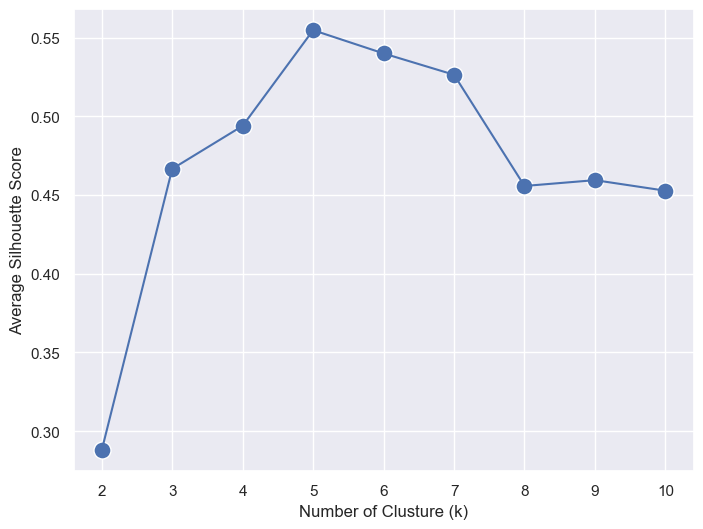

In [41]:
from sklearn.metrics import silhouette_score
silhouette = []

for k in range (2,11):
    km = KMeans(n_clusters=k, n_init=25, random_state=1234)
    km.fit(customers_scaled)
    silhouette.append(silhouette_score(customers_scaled, km.labels_))

silhouette_series = pd.Series(silhouette, index=range(2,11))

plt.figure(figsize=(8,6))
ax = sns.lineplot(y=silhouette_series, x=silhouette_series.index)
ax = sns.scatterplot(y=silhouette_series, x=silhouette_series.index, s=150)
ax = ax.set(xlabel='Number of Clusture (k)', ylabel='Average Silhouette Score')


In [42]:
# The k value correspond to the highest average silhouette score represents the optimal number of
# clustures. From chart we see 5 is the suggested value for k. The two approach suggest k is equal 
# to 5. The third statistical approach we use is the calinski-harabasz score.

##### Calinski-Harabasz Score

C:\Users\dkhan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dkhan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dkhan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dkhan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

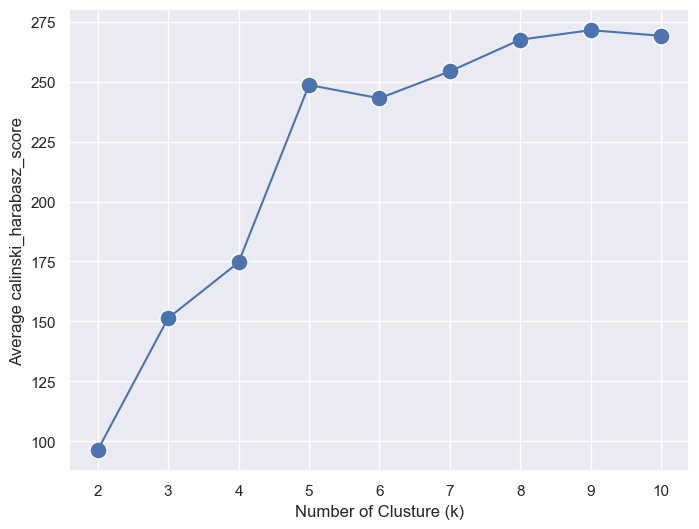

In [43]:
from sklearn.metrics import calinski_harabasz_score
calinski = []

for k in range (2,11):
    km = KMeans(n_clusters=k, n_init=25, random_state=1234)
    km.fit(customers_scaled)
    calinski.append(calinski_harabasz_score(customers_scaled, km.labels_))

calinski_series = pd.Series(calinski, index=range(2,11))

plt.figure(figsize=(8,6))
ax = sns.lineplot(y=calinski_series, x=calinski_series.index)
ax = sns.scatterplot(y=calinski_series, x=calinski_series.index, s=150)
ax = ax.set(xlabel='Number of Clusture (k)', ylabel='Average calinski_harabasz_score')

In [44]:
# Based on plot, the optimal value for k is that which correspond to either the highest score or 
# the first abrupt elbow in the chart. The highest value of k is equal to 9, but the first abrupt
# elbow is at equal to five.

In [45]:
# the three statistical approach suggest the value of k is equal to 5.

##### 6. Analyze and Interpret the Clustures

In [46]:
km = KMeans(n_clusters=5, n_init=25, random_state=1234)  # n_cliustures is equal to 5.
km.fit(customers_scaled)

C:\Users\dkhan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",25
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",1234
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [47]:
cluster_centers = pd.DataFrame(km.cluster_centers_, columns=['Income', 'SpendingScore'])

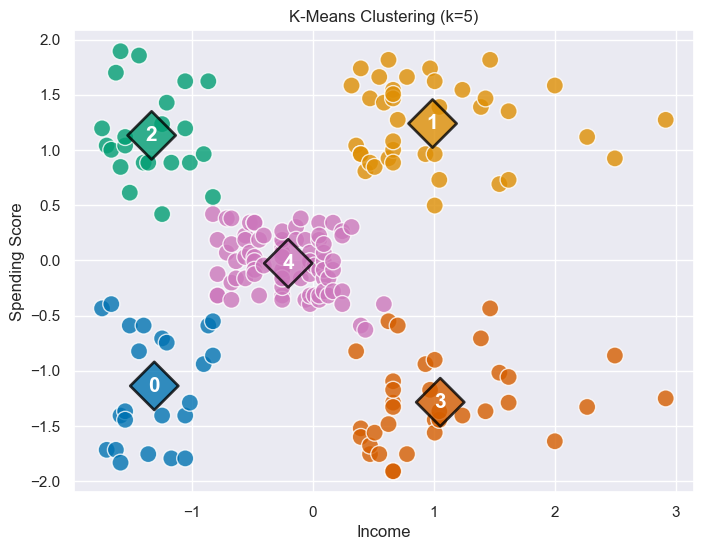

In [48]:
plt.figure(figsize=(8, 6))

# plot the clusters
ax = sns.scatterplot(data=customers_scaled,
                     x='Income',
                     y='SpendingScore',
                     hue=km.labels_,
                     palette='colorblind',
                     alpha=0.8,
                     s=150,
                     legend=False)

# plot the centroids
ax = sns.scatterplot(data=cluster_centers,
                     x='Income',
                     y='SpendingScore',
                     hue=cluster_centers.index,
                     palette='colorblind',
                     alpha=0.8,
                     s=600,
                     marker='D',
                     ec='black',
                     legend=False)

# Add centroids labels
for i in range(len(cluster_centers)):
    plt.text(x=cluster_centers.Income[i],
             y=cluster_centers.SpendingScore[i],
             s=i,
             horizontalalignment='center',
             verticalalignment='center',
             size=15,
             weight='bold',
             color='white')
#plt.xlim(-3, 3)
plt.title('K-Means Clustering (k=5)')
plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.show()           

In [49]:
# Here cluster 0 required more attention. cluster 3 and 1 remain the same.

In [50]:
customers['Cluster'] = km.labels_.tolist()
customers.head()

,CustomerID,Gender,Age,Income,SpendingScore,Cluster
0,1,Male,19,15000,39,0
1,2,Male,21,15000,81,2
2,3,Female,20,16000,6,0
3,4,Female,23,16000,77,2
4,5,Female,31,17000,40,0


In [51]:
customers = pd.get_dummies(customers, columns=['Gender'])
customers.head()

,CustomerID,Age,Income,SpendingScore,Cluster,Gender_Female,Gender_Male
0,1,19,15000,39,0,False,True
1,2,21,15000,81,2,False,True
2,3,20,16000,6,0,True,False
3,4,23,16000,77,2,True,False
4,5,31,17000,40,0,True,False


In [52]:
customers['Gender_M'] = customers['Gender_Male'].astype(int)
customers['Gender_F'] = customers['Gender_Female'].astype(int)

In [53]:
customers = customers.drop(columns=['Gender_Male', 'Gender_Female'])
customers.head()

,CustomerID,Age,Income,SpendingScore,Cluster,Gender_M,Gender_F
0,1,19,15000,39,0,1,0
1,2,21,15000,81,2,1,0
2,3,20,16000,6,0,0,1
3,4,23,16000,77,2,0,1
4,5,31,17000,40,0,0,1


In [54]:
customers.agg({
    'Gender_M': 'mean',
    'Gender_F': 'mean',
    'Age': 'median',
    'Income': 'median',
    'SpendingScore': 'median'}).round(2)



Gender_M             0.44
Gender_F             0.56
Age                 36.00
Income           61500.00
SpendingScore       50.00
dtype: float64

In [55]:
# 56% are female.
# Next descriptive statistics for the same features, but grouped by clustures.

In [56]:
customers.groupby('Cluster').agg({
    'Gender_M': 'mean',
    'Gender_F': 'mean',
    'Age': 'median',
    'Income': 'median',
    'SpendingScore': 'median'}).round(2)

,Gender_M,Gender_F,Age,Income,SpendingScore
Cluster,,,,,
0,0.39,0.61,46.0,25000.0,17.0
1,0.46,0.54,32.0,79000.0,83.0
2,0.41,0.59,23.5,24500.0,77.0
3,0.54,0.46,42.0,85000.0,16.0
4,0.41,0.59,46.0,54000.0,50.0


In [57]:
# Customers in cluster has the high spending power. The least Spending Score for cluster 3. 
#So, the cluster 1 mimic the gender distribution of the entire dataset. The gender distribution of
# cluster 2 also mimics the entire data set.